In [1]:
import pykasso as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import plotly.graph_objects as go
import networkx as nx
import importlib
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
# import cfpy

In [50]:
import utils.common
import utils.conduits
importlib.reload(utils.common)
importlib.reload(utils.conduits)
from utils.common import *
from utils.geos import * 
from utils.conduits import *

In [43]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

# Generate Single Straight Line Conduit

In [20]:
nodes = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/nodes.csv')
edges = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/edges.csv')

In [21]:
plot_3D_network(nodes, edges, node_color='type')

In [24]:
edges['length'] = np.sqrt((edges.x_0 - edges.x_1)**2 + (edges.y_0 - edges.y_1)**2 + (edges.z_0 - edges.z_1)**2)

In [25]:
edges

,from_id,to_id,x_0,y_0,z_0,x_1,y_1,z_1,length
0,0.0,2.0,558515.000000,4.867230e+06,395.320007,558502.725330,4.867266e+06,394.994499,38.19167
1,2.0,3.0,558502.725330,4.867266e+06,394.994499,558490.450660,4.867302e+06,394.668991,38.19167
2,3.0,4.0,558490.450660,4.867302e+06,394.668991,558478.175989,4.867338e+06,394.343482,38.19167
3,4.0,5.0,558478.175989,4.867338e+06,394.343482,558465.901319,4.867375e+06,394.017974,38.19167
4,5.0,6.0,558465.901319,4.867375e+06,394.017974,558453.626649,4.867411e+06,393.692466,38.19167
...,...,...,...,...,...,...,...,...,...
56,57.0,58.0,557827.618469,4.869255e+06,377.091542,557815.343799,4.869291e+06,376.766033,38.19167
57,58.0,59.0,557815.343799,4.869291e+06,376.766033,557803.069129,4.869328e+06,376.440525,38.19167
58,59.0,60.0,557803.069129,4.869328e+06,376.440525,557790.794458,4.869364e+06,376.115017,38.19167
59,60.0,61.0,557790.794458,4.869364e+06,376.115017,557778.519788,4.869400e+06,375.789508,38.19167


# Generate Straight Line Multi-conduit Network

In [51]:
new_nodes = pd.read_csv('../../data/networks/multiconduit/straight_n5/nodes.csv', index_col=False)
new_edges = pd.read_csv('../../data/networks/multiconduit/straight_n5/edges.csv', index_col=False)
new_edges = extract_edge_coordinates(new_nodes, new_edges)
new_nodes, new_edges = densify_edges(new_nodes, new_edges, density_factor=20)
new_nodes, new_edges = reset_node_ids(new_nodes, new_edges)

In [37]:
new_edges['length'] =  np.sqrt((new_edges.x_0 - new_edges.x_1)**2 + (new_edges.y_0 - new_edges.y_1)**2 + (new_edges.z_0 - new_edges.z_1)**2)

In [55]:
new_nodes.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/nodes.csv', index = False)
new_edges.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/edges.csv', index = False)

In [53]:
plot_3D_network(new_nodes, new_edges, node_color='type')

# Generate Network with PyKasso

In [4]:
app = pk.pykasso()
# Create a new project and declare its parameters
app.new_project(name=name, grid_parameters=grid_parameters)
app.visualizer.notebook = True
nx, ny, nz = app.project.grid.shape

In [5]:
top = np.load('../../data/DEM/dem_grid_bear_spring.npy').T
model_parameters['domain']['topography'] = top

In [6]:
for i in range(1):
    app.model.generate(model_parameters)
    # print(app.model.model_parameters['sks']['seed'])


In [7]:
edges = pd.DataFrame.from_dict(app.model.vectors['edges'], orient = 'index')
nodes = pd.DataFrame.from_dict(app.model.vectors['nodes'], orient ='index')
nodes.columns = ['x', 'y', 'z', 'type']
nodes = nodes.reset_index().rename({'index':'id'}, axis=1)
edges.columns = ['from_id', 'to_id']
edges = extract_edge_coordinates(nodes, edges)

In [10]:
plot_3D_network(nodes, edges, node_color = 'type')

In [11]:
from scipy.signal import savgol_filter

def smooth_network_df(
    df,
    window=7,
    poly=3,
    keep_types=("inlet", "outlet")
):
    """
    Smooth x,y,z coordinates in a network dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: x, y, z, type
        Must be ordered along conduit.

    window : int
        Smoothing window (odd number).

    poly : int
        Polynomial order.

    keep_types : tuple
        Node types to keep fixed.

    Returns
    -------
    pd.DataFrame
        Smoothed dataframe
    """

    df = df.copy()

    # Mask for movable nodes
    movable = ~df["type"].isin(keep_types)

    # If too few movable points → skip
    if movable.sum() < window:
        return df

    # Extract arrays
    x = df.loc[movable, "x"].to_numpy()
    y = df.loc[movable, "y"].to_numpy()
    z = df.loc[movable, "z"].to_numpy()

    # Ensure window is valid
    if window >= len(x):
        window = len(x) // 2 * 2 + 1  # nearest odd

    # Smooth
    x_s = savgol_filter(x, window, poly)
    y_s = savgol_filter(y, window, poly)
    z_s = savgol_filter(z, window, poly)

    # Put back
    df.loc[movable, "x"] = x_s
    df.loc[movable, "y"] = y_s
    df.loc[movable, "z"] = z_s

    return df


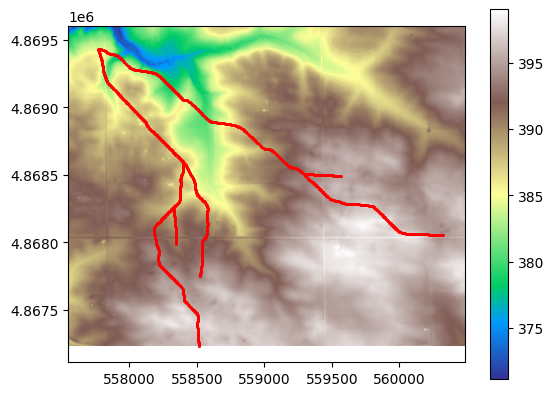

In [185]:
plt.imshow(top.T, extent=(x0, x1, y0, y1), origin='upper', cmap='terrain')
plt.colorbar()
plt.scatter(nodes['x'], nodes['y'], c='r', s=1)

In [186]:
plot_3D_network(nodes, edges, node_color='type')

## Quantify 